In [2]:
import numpy as np

from datetime import datetime, timedelta
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
    KnownTurnRate,
)
from stonesoup.types.groundtruth import GroundTruthState, GroundTruthPath

from nereus.platform import TowedArrayPlatform
from nereus.models.environment import Munk, Constant, Linear, FlatBathymetry
from nereus.models.propagation import CylindricalAcousticPropagationModel, rtrsAcousticPropagationModel
from nereus.signal.anthropogenic import BroadbandShipSignal
from nereus.signal.ambient import ColouredNoise
from nereus.simulator import BroadbandPassiveSonarArraySimulator
from nereus.sigproc import DelayAndSumBeamformer, SteeringCalculator, MinimumVarianceDistortionlessResponseBeamformer
from nereus.detector import CFARDetector, PassiveSonarDetector, PeakDetector
from nereus.plotter import BearingsPlotter

seed = 12
print(f"seed: {seed}")
np.random.seed(seed)

def random_start_vector(X, Vx, Y, Vy):
    return np.array([
        np.random.uniform(X[0], X[1]),
        np.random.uniform(Vx[0], Vx[1]),
        np.random.uniform(Y[0], Y[1]),
        np.random.uniform(Vy[0], Vy[1]),
        -5,
        0,
    ])

def generate_random_maneuvers(total_duration_s, timestep_s, min_leg_duration_s=60, max_leg_duration_s=300, maneuver_prob=0.5):
    """Generate random sequence of straight/turn maneuvers. manoeuvrers
    
    Args:
        total_duration_s: Total simulation time in seconds
        timestep_s: Simulation timestep in seconds
        min_leg_duration_s: Minimum duration for each leg
        max_leg_duration_s: Maximum duration for each leg
        maneuver_prob: Probability of performing a turn maneuver at each leg
    
    Returns:
        maneuver_models: List of transition models (3D)
        maneuver_timesteps: List of timestep indices where transitions occur
        maneuver_descriptions: List of string descriptions for logging
    """
    maneuver_models = []
    maneuver_timesteps = []
    maneuver_descriptions = []
    
    current_time = 0.0
    current_timestep = 0
    
    while current_time < total_duration_s - min_leg_duration_s:
        # Random leg duration (round to nearest timestep)
        leg_duration = np.random.uniform(min_leg_duration_s, max_leg_duration_s)
        leg_duration = round(leg_duration / timestep_s) * timestep_s
        leg_duration = min(leg_duration, total_duration_s - current_time)
        
        # Decide maneuver
        if np.random.rand() > maneuver_prob:
            # Straight leg
            model = CombinedLinearGaussianTransitionModel([
                ConstantVelocity(0.0), 
                ConstantVelocity(0.0), 
                ConstantVelocity(0.0)
            ])
            description = f"Straight ({leg_duration:.0f}s)"
        else:
            # Random turn: -90° to +90° (negative = right turn, positive = left turn)
            turn_angle_deg = np.random.uniform(-90, 90)
            turn_rate_deg_per_s = 1.0  # Standard turn rate
            
            # Calculate actual turn duration based on angle
            turn_duration_s = abs(turn_angle_deg) / turn_rate_deg_per_s
            turn_duration_s = round(turn_duration_s / timestep_s) * timestep_s
            leg_duration = min(turn_duration_s, total_duration_s - current_time)
            
            turn_rate_rad = np.deg2rad(np.sign(turn_angle_deg) * turn_rate_deg_per_s)
            
            turning_2d = KnownTurnRate(
                turn_rate=turn_rate_rad,
                turn_noise_diff_coeffs=np.array([0.0, 0.0])
            )
            
            model = CombinedLinearGaussianTransitionModel([
                turning_2d,
                ConstantVelocity(0.0)  # Constant depth
            ])
            
            direction = "Left" if turn_angle_deg > 0 else "Right"
            description = f"{direction} Turn {abs(turn_angle_deg):.0f}° ({leg_duration:.0f}s)"
        
        maneuver_models.append(model)
        maneuver_timesteps.append(current_timestep)
        maneuver_descriptions.append(description)
        
        current_time += leg_duration
        current_timestep = int(current_time / timestep_s)
    
    return maneuver_models, maneuver_timesteps, maneuver_descriptions


/home/fin/miniconda3/envs/nereus-env/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


seed: 12


/home/fin/miniconda3/envs/nereus-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# SIMULATION PARAMETERS

In [3]:
# ============================================================================
# SIMULATION PARAMETERS
# ============================================================================

SIM_LENGTH = 900 # seconds
SIM_RATE = 5.0 # seconds

Xlim = [-15_000, 15_000]
Ylim = [-15_000, 15_000]

NUM_TARGETS = 3

SIM_PARAMS = {
    "start_time":datetime.now().replace(hour=0, minute=0, second=0, microsecond=0),
    "time_interval":timedelta(seconds=SIM_RATE),
    "num_steps":int(SIM_LENGTH / SIM_RATE),
}

total_duration_s = SIM_PARAMS["num_steps"] * SIM_PARAMS["time_interval"].total_seconds()
print(f"Total simulation duration: {total_duration_s} seconds")
print(f"Number of timesteps: {SIM_PARAMS['num_steps']}, Timestep interval: {SIM_PARAMS['time_interval'].total_seconds()} seconds")

SHIP_PARAMS = {
    "start_vector": random_start_vector(Xlim, [-4,4], Ylim, [-4, 4]), 
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
}

ARRAY_PARAMS = {
    "num_sensors": 200,  
    "tow_cable_length": 100.0,
    "sensor_spacing": 0.5,
    "array_depth": -50.0,
}

TARGETS = []

for i in range(NUM_TARGETS):
    TARGET_PARAMS = {
        "start_vector": random_start_vector(Xlim, [-10.5,10.5], Ylim, [-10.5, 10.5]),  
        "position_mapping": [0, 2, 4],
        "velocity_mapping": [1, 3, 5],
        "transition_model": CombinedLinearGaussianTransitionModel(
            [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
        ),
        "amplitudes_upa": 10 ** (np.random.uniform(87, 102, 4) / 20),
        "frequencies_hz": np.random.uniform(25.0, 200.0, 4),
        "phases_rad": np.random.uniform(0, 2 * np.pi, 4),
        "tonal_bandwidth_hz": np.random.uniform(0.5, 2.0),
        "noise_amplitude_upa":10 ** (np.random.uniform(65, 85) / 20),
        "noise_spectral_exponent":-1.0,
    }
    TARGETS.append(TARGET_PARAMS)

SIGNAL_PARAMS = {
    "duration_s": total_duration_s,
    "sampling_rate_hz": 500.0, 
    "frame_len": 500,
    "hop_factor": 2,
    "fade_in_ms": 1000.0,
}

AMBIENT_NOISE_PARAMS = {
    "amplitude_upa": 10 ** (np.random.uniform(45, 55) / 20),  
    "spectral_exponent": -1,  
}

PROP_PARAMS = {
    # "ssp": Constant(speed=1500.0), 
    "ssp": Linear(surface_speed=1500.0, gradient=0.2),
    # "ssp": Munk(),
    "attenuation_factor": 0.5, 
    "bathymetry": FlatBathymetry(depth=-150.0),
    # "bathymetry": FlatBathymetry(depth=-5000.0),
    "step_m": 20.0,
    "azimuth_search_width": 2.0,
    "azimuth_resolution": 0.5,
    "elevation_range": (-25.0, 25.0),
    "elevation_resolution": 1.0,
}

BF_PARAMS = {
    "beamformer_type": "DAS",
    "shading": None,
    # "shading": "blackman",
    "domain": "frequency",
    "steering_azimuths_rad": np.linspace(-np.pi, np.pi, 361), 
}
# BF_PARAMS = {
#     "beamformer_type": "DAS",
#     "shading": None,    # shading is only for DAS, does nothing with MVDR
#     # "shading": "blackman",
#     "domain": "broadband_power",  # "time", "frequency", or "broadband_power" for DAS only
#     "steering_azimuths_rad": np.linspace(-np.pi, np.pi, 181), 
#     "fmin": 170.0,
#     "fmax": 195.0,
#     # "fmin": None,
#     # "fmax": None,
# }

# Detection parameters
DET_PARAMS = {
    "cfar_detector": {
        "num_guard_cells": 2,
        "num_training_cells": 5,
        "threshold_factor": 1.05,  
    },
    "peak_detector": {
        "distance": 3,  
    }
}

Total simulation duration: 900.0 seconds
Number of timesteps: 180, Timestep interval: 5.0 seconds


# SETUP

In [4]:
# ============================================================================
# SETUP
# ============================================================================

# Generate random maneuvers for platform
print("Generating random platform maneuvers...")
maneuver_models, maneuver_timesteps, maneuver_descriptions = generate_random_maneuvers(
    total_duration_s=total_duration_s,
    timestep_s=SIM_PARAMS["time_interval"].total_seconds(),
    min_leg_duration_s=60,
    max_leg_duration_s=300,  
    maneuver_prob=0.15
)

# Create platform
print("Creating platform...")
initial_state = GroundTruthState(
    SHIP_PARAMS["start_vector"], timestamp=SIM_PARAMS["start_time"]
)

platform = TowedArrayPlatform(
    states=[initial_state],
    position_mapping=SHIP_PARAMS["position_mapping"],
    velocity_mapping=SHIP_PARAMS["velocity_mapping"],
    transition_model=maneuver_models[0],  # Start with first maneuver
    num_sensors=ARRAY_PARAMS["num_sensors"],
    cable_length_m=ARRAY_PARAMS["tow_cable_length"],
    sensor_spacing_m=ARRAY_PARAMS["sensor_spacing"],
    array_depth_m=ARRAY_PARAMS["array_depth"],
)

# Move platform through all timesteps with maneuver transitions
print("Moving platform through scenario...")
current_maneuver_idx = 0

for i in range(1, SIM_PARAMS["num_steps"]):
    # Check if we need to switch maneuvers
    if current_maneuver_idx < len(maneuver_timesteps) - 1:
        next_maneuver_timestep = maneuver_timesteps[current_maneuver_idx + 1]
        if i >= next_maneuver_timestep:
            current_maneuver_idx += 1
            platform.movement_controller.transition_model = maneuver_models[current_maneuver_idx]
    
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    platform.move(new_time)

# Create target trajectories
print(f"Creating {NUM_TARGETS} target trajectories with random maneuvers...")
target_ground_truths = []
relative_bearing_ground_truths = []

for target_idx, TARGET_PARAMS in enumerate(TARGETS):

    # Create initial state
    target_states = [
        GroundTruthState(
            TARGET_PARAMS["start_vector"],
            timestamp=SIM_PARAMS["start_time"],
            metadata={
                "amplitudes_upa": TARGET_PARAMS["amplitudes_upa"],
                "frequencies_hz": TARGET_PARAMS["frequencies_hz"],
                "phases_rad": TARGET_PARAMS["phases_rad"],
                "position_mapping": TARGET_PARAMS["position_mapping"],
                "velocity_mapping": TARGET_PARAMS["velocity_mapping"],
                "tonal_bandwidth_hz": TARGET_PARAMS["tonal_bandwidth_hz"],
                "noise_amplitude_upa": TARGET_PARAMS["noise_amplitude_upa"],
                "noise_spectral_exponent": TARGET_PARAMS["noise_spectral_exponent"],
            },
        )
    ]

    # Propagate trajectory with multi-transition models
    current_maneuver_idx = 0
    
    for i in range(1, SIM_PARAMS["num_steps"]):

        transition_model = TARGET_PARAMS["transition_model"]
        new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        time_interval = new_time - target_states[-1].timestamp
        new_state_vector = transition_model.function(
            target_states[-1], noise=False, time_interval=time_interval
        )
        new_state = GroundTruthState(
            new_state_vector,
            timestamp=new_time,
            metadata=target_states[-1].metadata,
        )
        target_states.append(new_state)

    target_ground_truth = GroundTruthPath(target_states)
    target_ground_truths.append(target_ground_truth)
    
    # Compute ground truth bearings for plotting
    gt_relative_bearings = []
    for target_state in target_ground_truth.states:
        platform_state = platform.get_platform_state_at(target_state.timestamp)
        ref_sensor_position = np.mean(platform_state.array.state_vector, axis=1)
        target_pos = np.array([target_state.state_vector[0], target_state.state_vector[2]])
        relative_pos = target_pos - ref_sensor_position[:2]
        bearing_rad = np.arctan2(relative_pos[1], relative_pos[0])
        gt_relative_bearings.append(bearing_rad)
    
    gt_relative_bearings = np.array(gt_relative_bearings)
    
    # Create GroundTruthPath for bearings
    relative_bearing_truth_states = []
    for i, bearing in enumerate(gt_relative_bearings):
        timestamp = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        bearing_state = GroundTruthState(
            state_vector=np.array([bearing]),
            timestamp=timestamp
        )
        relative_bearing_truth_states.append(bearing_state)
    
    relative_bearing_ground_truth = GroundTruthPath(relative_bearing_truth_states)
    relative_bearing_ground_truths.append(relative_bearing_ground_truth)

# Create signal and propagation models
print("Creating signal and propagation models...")

# prop_model = CylindricalAcousticPropagationModel(
#     ssp=PROP_PARAMS["ssp"],
#     attenuation_factor=PROP_PARAMS["attenuation_factor"],
# )

prop_model = rtrsAcousticPropagationModel(
    ssp=PROP_PARAMS["ssp"],
    bathymetry=PROP_PARAMS["bathymetry"],
    use_all_frequencies=False,  # Will use propagate_spectrum
    step_m=20.0,
    azimuth_search_width=2.0,
    azimuth_resolution=0.5,
    elevation_range=(-25.0, 25.0),
    elevation_resolution=1.0,
)

# Create ambient noise model
ambient_noise_model = ColouredNoise(
    amplitude_upa=AMBIENT_NOISE_PARAMS["amplitude_upa"],
    spectral_exponent=AMBIENT_NOISE_PARAMS["spectral_exponent"],
    duration_s=SIM_PARAMS["time_interval"].total_seconds(),
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
)

# Create beamformer and steering calculator
print("Creating beamformer and steering calculator...")
from scipy.signal import get_window

shading = None
if BF_PARAMS["shading"] is not None:
    shading = get_window(BF_PARAMS["shading"], platform.num_sensors)

if BF_PARAMS["beamformer_type"] == "DAS":
    if BF_PARAMS["domain"] == "broadband_power":
        beamformer = DelayAndSumBeamformer(
            domain=BF_PARAMS["domain"],
            sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
            fmin=BF_PARAMS["fmin"],
            fmax=BF_PARAMS["fmax"],
        )
    else:
        beamformer = DelayAndSumBeamformer(
            sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
            shading=shading,
            domain=BF_PARAMS["domain"]
        )
elif BF_PARAMS["beamformer_type"] == "MVDR":

    beamformer = MinimumVarianceDistortionlessResponseBeamformer(
        sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
        fmin=BF_PARAMS["fmin"],
        fmax=BF_PARAMS["fmax"],
    )
else:
    raise ValueError(f"Unknown beamformer type: {BF_PARAMS['beamformer_type']}")

# beamformer = MinimumVarianceDistortionlessResponseBeamformer(
#     sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
#     fmin=100.0,
#     fmax=125.0,
# )

steering_calculator = SteeringCalculator(
    ssp=PROP_PARAMS["ssp"],
    steering_azimuths_rad=BF_PARAMS["steering_azimuths_rad"],
)

# Create signal models for each target
print("Creating signal models for each target...")
signal_models = []
for target_idx, TARGET_PARAMS in enumerate(TARGETS):
    signal_model = BroadbandShipSignal(
        duration_s=SIGNAL_PARAMS["duration_s"],
        sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
        frame_len=SIGNAL_PARAMS["frame_len"],
        hop_factor=SIGNAL_PARAMS["hop_factor"],
        tonal_bandwidth_hz=TARGET_PARAMS["tonal_bandwidth_hz"],
        noise_amplitude_upa=TARGET_PARAMS["noise_amplitude_upa"],
        noise_spectral_exponent=TARGET_PARAMS["noise_spectral_exponent"],
        noise_freq_range_hz=(0.0, SIGNAL_PARAMS["sampling_rate_hz"]/2),
        tonal_noise_is_constant=True,
        noise_is_constant=True,
    )
    signal_models.append(signal_model)

# Use the first signal model for simplicity (have same time/freq params but different source signal)
signal_model = signal_models[0]

# Create simulator with beamforming
print("Creating broadband simulator with beamforming...")
simulator = BroadbandPassiveSonarArraySimulator(
    platform=platform,
    propagation_model=prop_model,
    signal_model=signal_model,
    noise_model=ambient_noise_model,
    beamformer=beamformer,
    steering_calculator=steering_calculator,
    ground_truth_paths=target_ground_truths,
    fade_in_ms=SIGNAL_PARAMS["fade_in_ms"],
)


for target_idx, TARGET_PARAMS in enumerate(TARGETS):
    print(f"  Target {target_idx + 1}:")
    print(f"    Frequencies: {TARGET_PARAMS['frequencies_hz']} Hz")
    print(f"    Amplitudes: {20 * np.log10(TARGET_PARAMS['amplitudes_upa'])} dB re 1 µPa")
    print(f"    Start Position: ({TARGET_PARAMS['start_vector'][0]:.0f}, {TARGET_PARAMS['start_vector'][2]:.0f}) m")
    print(f"    Velocity: ({TARGET_PARAMS['start_vector'][1]:.1f}, {TARGET_PARAMS['start_vector'][3]:.1f}) m/s")
    print(f"    Bandwidth: {TARGET_PARAMS['tonal_bandwidth_hz']} Hz")
    print(f"    Noise Amplitude: {20 * np.log10(TARGET_PARAMS['noise_amplitude_upa'])} dB re 1 µPa")


Generating random platform maneuvers...
Creating platform...
Moving platform through scenario...
Creating 3 target trajectories with random maneuvers...
Creating signal and propagation models...
Creating beamformer and steering calculator...
Creating signal models for each target...
Creating broadband simulator with beamforming...
  Target 1:
    Frequencies: [190.23939881 174.22871969  25.39536587 116.21455476] Hz
    Amplitudes: [101.35424004  89.05813982  91.25742529  96.09124777] dB re 1 µPa
    Start Position: (-14563, 12021) m
    Velocity: (8.8, -9.8) m/s
    Bandwidth: 1.6468406755083183 Hz
    Noise Amplitude: 65.41619595904132 dB re 1 µPa
  Target 2:
    Frequencies: [147.95891217  82.32465835  83.56331759 196.16016383] Hz
    Amplitudes: [94.06844667 99.24252447 91.34380175 97.99688966] dB re 1 µPa
    Start Position: (-10944, -5703) m
    Velocity: (-8.1, 3.6) m/s
    Bandwidth: 1.1099604527099924 Hz
    Noise Amplitude: 74.02616822842629 dB re 1 µPa
  Target 3:
    Frequen

# RUN SIMULATION WITH DETECTION

In [5]:
# ============================================================================
# RUN SIMULATION WITH DETECTION
# ============================================================================

data_generator = simulator.sensor_data_gen()

# Create detection chain
cfar_detector = CFARDetector(
    num_guard_cells=DET_PARAMS["cfar_detector"]["num_guard_cells"],
    num_training_cells=DET_PARAMS["cfar_detector"]["num_training_cells"],
    threshold_factor=DET_PARAMS["cfar_detector"]["threshold_factor"],
)
peak_detector = PeakDetector(distance=DET_PARAMS["peak_detector"]["distance"])

detection_chain = [cfar_detector]
detection_chain.append(peak_detector)

detector = PassiveSonarDetector(
    detection_chain=detection_chain,
    sensor_data_gen=data_generator,
    steering_azimuths_rad=BF_PARAMS["steering_azimuths_rad"]
)

# Run detection
print("Running detection chain...")
all_detections = list(detector.detections_gen(progress_bar=True))
snr_map = detector.snr_history

Running detection chain...


Generating Detections: 180it [02:05,  1.43it/s]


# VISUALIZATION

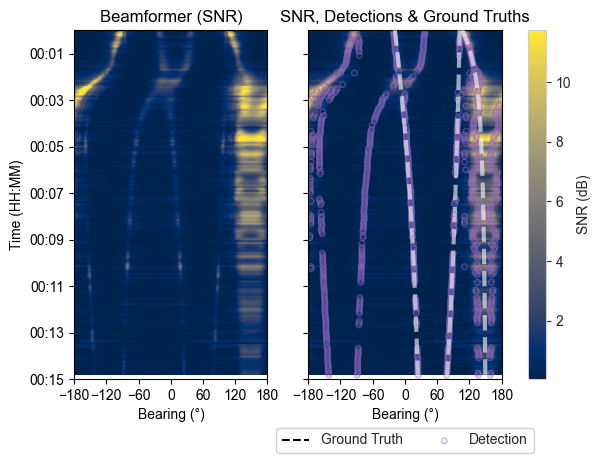

In [6]:
# ============================================================================
# VISUALIZATION
# ============================================================================

import matplotlib.pyplot as plt

timesteps = [
    SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    for i in range(SIM_PARAMS["num_steps"])
]

detections_for_plotter = [detection_set for _, detection_set in all_detections]

# Plot 1: Beamformer output with detections
fig1, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

style_guide = {
    "figure": {
        "figsize": (4, 4),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

# Left: Raw SNR (exclude last timestep)
plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=[],
    truths=[],
    ax=axs[0],
    add_colorbar=False
)
axs[0].set_title("Beamformer (SNR)")

# Right: SNR with detections and truth (exclude last timestep)
_, im = plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=detections_for_plotter[:-1],
    truths=relative_bearing_ground_truths,
    ax=axs[1],
    add_colorbar=False
)
axs[1].set_ylabel("")
axs[1].set_title(f"SNR, Detections & Ground Truths")

# Add shared colorbar
fig1.colorbar(im, ax=axs.tolist(), label='SNR (dB)')

# plt.suptitle(
#     f"Random Scenario: {NUM_TARGETS} Targets, {ARRAY_PARAMS['num_sensors']} Sensors",
#     fontsize=14,
#     fontweight="bold",
#     y=1.02
# )
plt.savefig("figs/beamformer_detections.png", dpi=300)


(<Axes: xlabel='Bearing (°)', ylabel='Time (HH:MM)'>,
 <matplotlib.image.AxesImage at 0x7fdbc831fdd0>)

<Figure size 640x480 with 0 Axes>

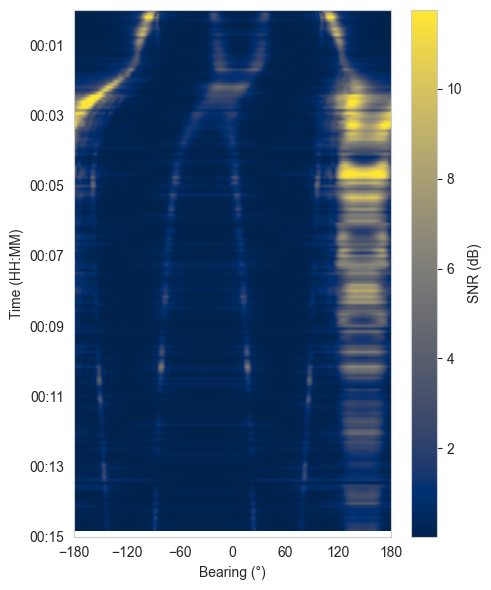

In [7]:
plt.figure()

style_guide = {
    "figure": {
        "figsize": (5, 6),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

# Left: Raw SNR (exclude last timestep)
plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=[],
    truths=[],
    add_colorbar=True
)

/tmp/ipykernel_358708/1677070620.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


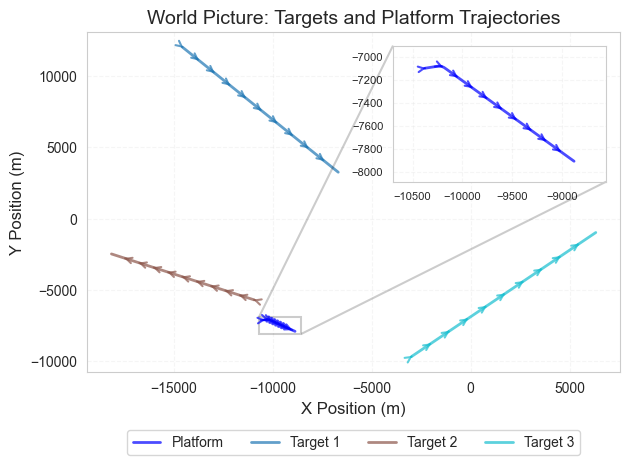

In [8]:
# Plot 2: Trajectories in Cartesian space
fig2, ax_path = plt.subplots()

# Extract platform positions
platform_x = []
platform_y = []
array_x = []
array_y = []

for timestamp in timesteps:
    platform_state = platform.get_platform_state_at(timestamp)
    platform_x.append(platform_state.host.state.state_vector[0])
    platform_y.append(platform_state.host.state.state_vector[2])
    
    array_center = np.mean(platform_state.array.state_vector, axis=1)
    array_x.append(array_center[0])
    array_y.append(array_center[1])

# Plot platform trajectory with direction arrows
ax_path.plot(platform_x, platform_y, 'b-', label='Platform', linewidth=2, alpha=0.7)
# ax_path.plot(array_x, array_y, 'g--', label='Array Center', linewidth=1.5, alpha=0.6)

# Add direction arrows for platform (every 10th point to avoid clutter)
arrow_interval = max(1, len(platform_x) // 10)
for i in range(0, len(platform_x) - 1, arrow_interval):
    dx = platform_x[i + 1] - platform_x[i]
    dy = platform_y[i + 1] - platform_y[i]
    ax_path.annotate('', xy=(platform_x[i + 1], platform_y[i + 1]), 
                    xytext=(platform_x[i], platform_y[i]),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, alpha=0.7))

# Plot target trajectories with different colors
colors = plt.cm.tab10(np.linspace(0, 1, NUM_TARGETS))

for target_idx, target_ground_truth in enumerate(target_ground_truths):
    target_x = [state.state_vector[0] for state in target_ground_truth]
    target_y = [state.state_vector[2] for state in target_ground_truth]
    
    color = colors[target_idx]
    ax_path.plot(target_x, target_y, '-', color=color, 
                label=f'Target {target_idx + 1}', linewidth=2, alpha=0.7)
    
    # Add direction arrows for each target (every 10th point)
    for i in range(0, len(target_x) - 1, arrow_interval):
        dx = target_x[i + 1] - target_x[i]
        dy = target_y[i + 1] - target_y[i]
        ax_path.annotate('', xy=(target_x[i + 1], target_y[i + 1]), 
                        xytext=(target_x[i], target_y[i]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.7))
    

ax_path.set_xlabel('X Position (m)', fontsize=12)
ax_path.set_ylabel('Y Position (m)', fontsize=12)
ax_path.set_title(f'World Picture: Targets and Platform Trajectories', fontsize=14)
ax_path.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=4)
ax_path.grid(True, alpha=0.3)
# ax_path.axis('equal')

# Create inset zoom of platform trajectory
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
ax_inset = inset_axes(ax_path, width="40%", height="40%", loc='upper right', 
                      borderpad=1.)

# Determine zoom region (all of platform trajectory)
mid_idx = len(platform_x) // 2
zoom_range = len(platform_x) 
zoom_start = max(0, mid_idx - zoom_range)
zoom_end = min(len(platform_x), mid_idx + zoom_range)

# Get bounds of zoom region
x_zoom = platform_x[zoom_start:zoom_end]
y_zoom = platform_y[zoom_start:zoom_end]
x_min, x_max = min(x_zoom), max(x_zoom)
y_min, y_max = min(y_zoom), max(y_zoom)

# --- add padding so arrows fit inside ---
pad_x = 0.15 * (x_max - x_min)
pad_y = 0.15 * (y_max - y_min)

x_min -= pad_x
x_max += pad_x
y_min -= pad_y
y_max += pad_y

# Add rectangle to show zoom region on main plot
from matplotlib.patches import Rectangle
zoom_box = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                     fill=False, edgecolor='Black', linewidth=1.5, 
                     linestyle='-', alpha=0.4)
# ax_path.add_patch(zoom_box)

# Plot zoomed platform trajectory
ax_inset.plot(platform_x[zoom_start:zoom_end], platform_y[zoom_start:zoom_end], 
              'b-', linewidth=2, alpha=0.7)

# Add direction arrows in inset
inset_arrow_interval = max(1, (zoom_end - zoom_start) // 10)
for i in range(zoom_start, zoom_end - 1, inset_arrow_interval):
    dx = platform_x[i + 1] - platform_x[i]
    dy = platform_y[i + 1] - platform_y[i]
    ax_inset.annotate('', xy=(platform_x[i + 1], platform_y[i + 1]), 
                     xytext=(platform_x[i], platform_y[i]),
                     arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, alpha=0.7))

ax_inset.grid(True, alpha=0.3)
ax_inset.tick_params(labelsize=8)
# ax_inset.set_aspect('equal')

# ax_inset.plot(array_x, array_y, 'g--', label='Array Center', linewidth=1.5, alpha=0.6)
# Expand inset limits slightly so arrows fit inside the mark_inset box
x_pad = 0.05 * (x_max - x_min)
y_pad = 0.05 * (y_max - y_min)

ax_inset.set_xlim(x_min - x_pad, x_max + x_pad)
ax_inset.set_ylim(y_min - y_pad, y_max + y_pad)

# Connect inset to zoom box with diagonal lines
mark_inset(
    ax_path,
    ax_inset,
    loc1=2,   # upper left corner of box
    loc2=4,   # lower right corner of box
    fc="none",
    ec="black",
    lw=1.5,
    alpha=0.2,

)


plt.tight_layout()

plt.savefig("figs/multi_target_world_picture.png", dpi=300)



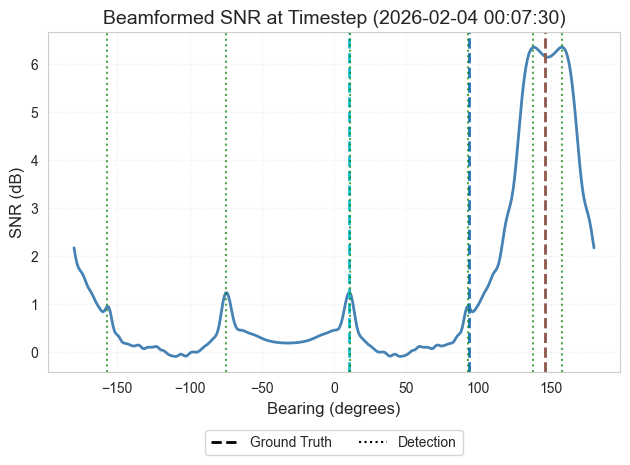

In [9]:
# Plot 3: Beamformed SNR at middle timestep
fig3, ax_middle = plt.subplots()

middle_timestep_idx = SIM_PARAMS["num_steps"] // 2
middle_snr = snr_map[middle_timestep_idx, :]
middle_time = timesteps[middle_timestep_idx]

steering_azimuths_deg = np.rad2deg(BF_PARAMS["steering_azimuths_rad"])
ax_middle.plot(steering_azimuths_deg, middle_snr, linewidth=2, color='steelblue')
ax_middle.set_xlabel('Bearing (degrees)', fontsize=12)
ax_middle.set_ylabel('SNR (dB)', fontsize=12)
ax_middle.set_title(f'Beamformed SNR at Timestep ({middle_time})', fontsize=14)
ax_middle.grid(True, alpha=0.3)

# Mark ground truth bearings for all targets
for target_idx, gt_relative_bearings in enumerate([
    [state.state_vector[0] for state in gt_path.states] 
    for gt_path in relative_bearing_ground_truths
]):
    gt_bearing_deg = np.rad2deg(gt_relative_bearings[middle_timestep_idx])
    color = colors[target_idx]
    ax_middle.axvline(gt_bearing_deg, color=color, linestyle='--', linewidth=2, 
                     label=f'Target {target_idx + 1} GT ({gt_bearing_deg:.1f}°)')

# Mark detections at this timestep if any
if len(detections_for_plotter[middle_timestep_idx]) > 0:
    for det_idx, det in enumerate(detections_for_plotter[middle_timestep_idx]):
        det_bearing_deg = np.rad2deg(det.state_vector[0])
        label = 'Detections' if det_idx == 0 else None
        ax_middle.axvline(det_bearing_deg, color='green', linestyle=':', linewidth=1.5, 
                        label=label, alpha=0.7)

# Create custom legend handles
from matplotlib.lines import Line2D
custom_handles = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Ground Truth'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=1.5, label='Detection')
]
ax_middle.legend(handles=custom_handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=2)
plt.tight_layout()

plt.savefig("figs/multi_target_beamformed_snr_slice.png", dpi=300)

# TARGET TRACKING

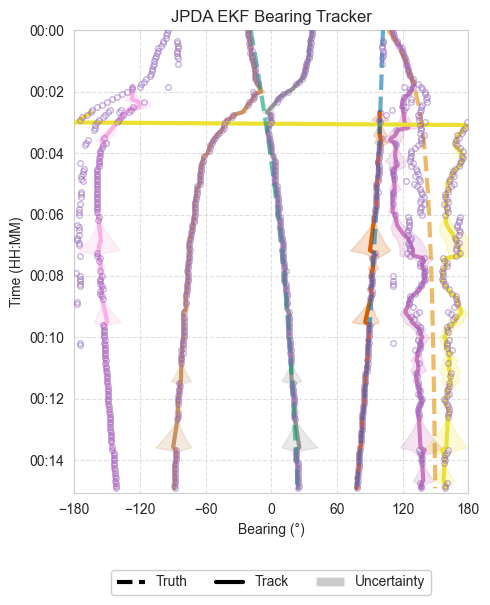

In [10]:
import numpy as np

from stonesoup.dataassociator.probability import JPDA
from stonesoup.functions import gm_reduce_single
from stonesoup.hypothesiser.probability import PDAHypothesiser

from stonesoup.hypothesiser.distance import DistanceHypothesiser
from stonesoup.dataassociator.neighbour import GNNWith2DAssignment
from stonesoup.measures import Mahalanobis

from stonesoup.deleter.error import CovarianceBasedDeleter
from stonesoup.initiator.simple import MultiMeasurementInitiator

from stonesoup.models.measurement.linear import LinearGaussian
from stonesoup.models.transition.linear import ConstantVelocity
from stonesoup.predictor.kalman import KalmanPredictor
from stonesoup.types.array import StateVectors
from stonesoup.types.state import GaussianState
from stonesoup.types.update import GaussianStateUpdate
from stonesoup.updater.kalman import ExtendedKalmanUpdater
from stonesoup.types.detection import MissedDetection

from stonesoup.functions import mod_bearing
from stonesoup.types.angle import Bearing

# ============================================================================
# Models
# ============================================================================
transition_model = ConstantVelocity(0.000001)
predictor = KalmanPredictor(transition_model)

measurement_model = LinearGaussian(
    ndim_state=2,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(1)**2]])
)
updater = ExtendedKalmanUpdater(measurement_model=measurement_model)

# ============================================================================
# JPDA for main tracking
# ============================================================================
FOV_RAD = np.deg2rad(360)
expected_false_alarms_per_scan = 6
clutter_spatial_density = expected_false_alarms_per_scan / FOV_RAD

jpda_hypothesiser = PDAHypothesiser(
    predictor=predictor,
    updater=updater,
    clutter_spatial_density=clutter_spatial_density,
    prob_detect=0.95
)
jpda_associator = JPDA(hypothesiser=jpda_hypothesiser)

# ============================================================================
# GNN for initiation (single-hypothesis, avoids MultipleHypothesis issue)
# ============================================================================
init_hypothesiser = DistanceHypothesiser(
    predictor=predictor,
    updater=updater,
    measure=Mahalanobis(),
    missed_distance=3.0
)
init_associator = GNNWith2DAssignment(init_hypothesiser)

# ============================================================================
# Track management
# ============================================================================
deleter = CovarianceBasedDeleter(covar_trace_thresh=0.3)

relative_bearing_ground_truth = relative_bearing_ground_truths[0]
initial_bearing = float(relative_bearing_ground_truth[0].state_vector[0]) + np.random.normal(0, np.deg2rad(2))
initial_bearing = mod_bearing(initial_bearing)

prior_state = GaussianState(
    np.array([[initial_bearing], [0.0]]),
    np.diag([np.deg2rad(5)**2, np.deg2rad(0.5)**2]),
    timestamp=SIM_PARAMS["start_time"]
)
Bearing(prior_state.state_vector[0,0])

initiator = MultiMeasurementInitiator(
    prior_state=prior_state,
    measurement_model=measurement_model,
    deleter=deleter,
    data_associator=init_associator, 
    updater=updater,
    min_points=2,
)

tracks, all_tracks = set(), set()

# ============================================================================
# Main loop
# ============================================================================
for timestamp, detections in all_detections:

    # Wrap detections
    for det in detections:
        det.state_vector[0, 0] = mod_bearing(float(det.state_vector[0, 0]))

    # JPDA association for existing tracks
    associations = jpda_associator.associate(set(tracks), detections, timestamp)

    associated_detections = set()

    for track in list(tracks):
        track_hypotheses = associations[track]  # MultipleHypothesis

        posterior_states = []
        posterior_weights = []

        for hyp in track_hypotheses:
            if (hyp.measurement is None) or isinstance(hyp.measurement, MissedDetection):
                state = hyp.prediction
                Bearing(state.state_vector[0,0])
            else:
                state = updater.update(hyp)
                Bearing(state.state_vector[0,0])
                associated_detections.add(hyp.measurement)

            posterior_states.append(state)
            posterior_weights.append(float(hyp.probability))

        means = StateVectors([s.state_vector for s in posterior_states])
        covars = np.stack([s.covar for s in posterior_states], axis=2)
        weights = np.asarray(posterior_weights, dtype=float)
        if weights.sum() > 0:
            weights /= weights.sum()

        post_mean, post_covar = gm_reduce_single(means, covars, weights)
        post_mean = post_mean.copy()
        post_mean[0, 0] = mod_bearing(float(post_mean[0, 0]))

        track.append(GaussianStateUpdate(post_mean, post_covar, track_hypotheses, timestamp))

    # Delete and initiate (initiation uses GNN associator)
    tracks -= deleter.delete_tracks(tracks)
    tracks |= initiator.initiate(detections - associated_detections, timestamp)
    all_tracks |= tracks

style_guide = {
    "figure": {
        "figsize": (5, 6),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=tracks,
    all_detections=detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)
plt.title("JPDA EKF Bearing Tracker")

plt.savefig("figs/multi_target_bearing_tracker.png", dpi=300)

/home/fin/Documents/python/nereus/nereus/plotter.py:238: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.tight_layout()


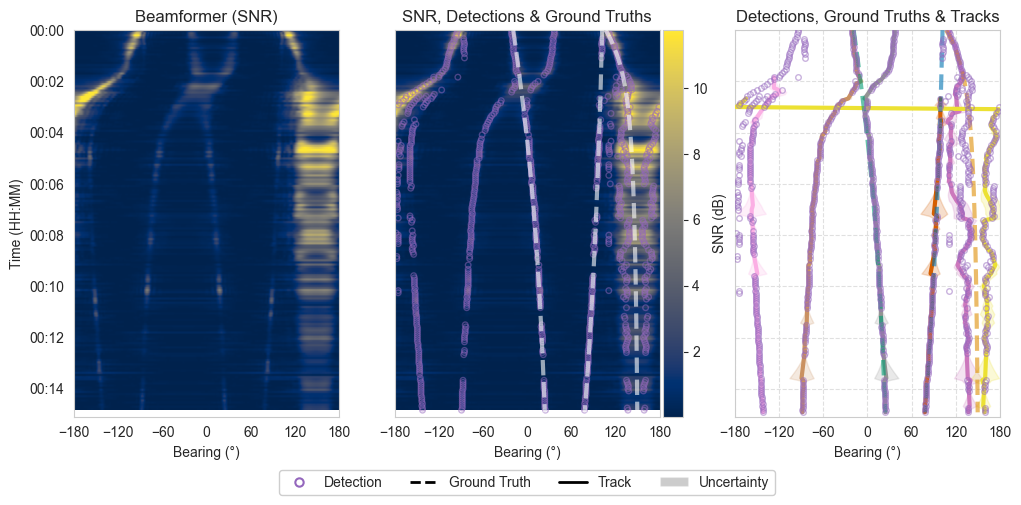

In [11]:
# Beamformer output with detections and tracks
fig1, axs = plt.subplots(1, 3, figsize=(10, 4.8), sharey=True, tight_layout=True)

style_guide = {
    "figure": {
        "figsize": (3, 4),
        "font_size": 10
    },
    "legend": {
        "display": False,  # Disable legend on RHS plot
    },
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

# Left: Raw SNR (exclude last timestep)
plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=[],
    truths=[],
    ax=axs[0],
    add_colorbar=False,
    add_legend=False
)
axs[0].set_title("Beamformer (SNR)")

# Middle: SNR with detections and truth (exclude last timestep)
_, im = plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=detections_for_plotter[:-1],
    truths=relative_bearing_ground_truths,
    ax=axs[1],
    add_colorbar=False,
    add_legend=False
)
axs[1].set_ylabel("")
axs[1].set_title(f"SNR, Detections & Ground Truths")

# Add shared colorbar
fig1.colorbar(im, ax=axs.tolist(), label='SNR (dB)', anchor=(-1.5, 0.5))

# Right: Detections, Ground Truths & Tracks (no legend)
plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=tracks,
    all_detections=detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    ax=axs[2],
    plot_uncertainty=True
)
axs[2].set_ylabel("")
axs[2].set_title(f"Detections, Ground Truths & Tracks")
pos = axs[2].get_position()
axs[2].set_position([pos.x0 + 0.02, pos.y0, pos.width, pos.height])

# Create unified legend under middle plot
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
           markeredgecolor='#9467bd', markersize=6, markeredgewidth=1.5, 
           label='Detection', linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label='Ground Truth'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=2, 
           label='Track'),
    Patch(facecolor='black', alpha=0.2, label='Uncertainty'),
]

axs[1].legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(0.5, -0.12), ncol=4, 
              fancybox=True, shadow=False, frameon=True, framealpha=0.95)

plt.savefig("figs/multi_target_beamformer_tracker.png", dpi=300, bbox_inches='tight')


# STONE SOUP DETECTIONS

<Axes: xlabel='Bearing (°)', ylabel='Time (HH:MM)'>

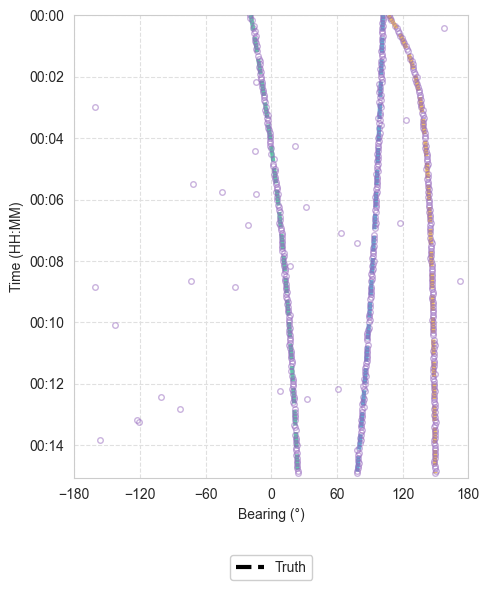

In [12]:
from stonesoup.types.detection import Detection
from scipy.stats import uniform

# Measurement model for bearing-only measurements
deg_std = 0.5
detection_measurement_model = LinearGaussian(
    ndim_state=1,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(deg_std)**2]])
)

# Measurement model for tracking (2D state -> 1D measurement)
ss_measurement_model = LinearGaussian(
    ndim_state=2,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(deg_std)**2]])
)

# Detection parameters
prob_detection = 0.95
FOV_RAD = np.deg2rad(360)
expected_false_alarms_per_scan = 1
clutter_spatial_density = expected_false_alarms_per_scan / FOV_RAD

# Generate detections from ground truth
stone_soup_detections = []

for i, timestamp in enumerate(timesteps):
    detections_at_time = []
    
    # Generate true detections from each target
    for gt_bearing_path in relative_bearing_ground_truths:
        if np.random.rand() < prob_detection:
            measurement = detection_measurement_model.function(gt_bearing_path[i], noise=True)
            
            detection = Detection(
                state_vector=measurement,
                timestamp=timestamp,
                measurement_model=ss_measurement_model
            )
            detections_at_time.append(detection)
    
    # Add clutter/false alarms
    num_clutter = np.random.poisson(clutter_spatial_density)
    for _ in range(num_clutter):
        clutter_bearing = uniform.rvs(loc=-np.pi, scale=2*np.pi)
        clutter_detection = Detection(
            state_vector=np.array([[clutter_bearing]]),
            timestamp=timestamp,
            measurement_model=ss_measurement_model
        )
        detections_at_time.append(clutter_detection)
    
    stone_soup_detections.append((timestamp, detections_at_time))

# Convert to format compatible with plotter
ss_detections_for_plotter = [detection_set for _, detection_set in stone_soup_detections]

style_guide = {
    "figure": {
        "figsize": (5, 6),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=[],
    all_detections=ss_detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)

Generating Stone Soup detections with left-right ambiguity...


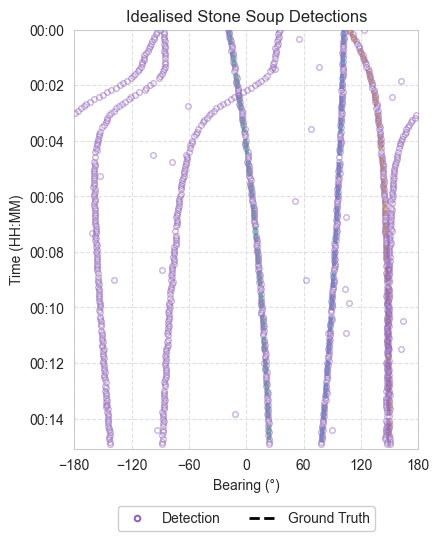

In [13]:
SS_DET_PARAMS = {
    "prob_detection": 0.95,
    "bearing_std_deg": 0.5,
    "fov_deg": 360.0,
    "expected_clutter_per_scan": 1,
    "include_ambiguity": True,
}

def compute_bearing_world_frame(platform_state, target_position):
    """Compute bearing from platform array center to target position in world frame."""
    array_center = np.mean(platform_state.array.state_vector, axis=1)
    relative_pos = target_position - array_center[:2]
    absolute_bearing = np.arctan2(relative_pos[1], relative_pos[0])
    return np.arctan2(np.sin(absolute_bearing), np.cos(absolute_bearing))

def generate_ambiguous_bearing(true_bearing_rad, platform_heading_rad):
    """Generate port/starboard ambiguous bearing."""
    ambiguous_bearing = 2 * platform_heading_rad - true_bearing_rad
    return np.arctan2(np.sin(ambiguous_bearing), np.cos(ambiguous_bearing))

# Measurement models
deg_std = SS_DET_PARAMS["bearing_std_deg"]
detection_measurement_model = LinearGaussian(
    ndim_state=1,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(deg_std)**2]])
)

ss_measurement_model = LinearGaussian(
    ndim_state=2,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(deg_std)**2]])
)

# Detection parameters
prob_detection = SS_DET_PARAMS["prob_detection"]
FOV_RAD = np.deg2rad(SS_DET_PARAMS["fov_deg"])
expected_false_alarms_per_scan = SS_DET_PARAMS["expected_clutter_per_scan"]
clutter_spatial_density = expected_false_alarms_per_scan / FOV_RAD

print("Generating Stone Soup detections with left-right ambiguity...")
stone_soup_detections = []

for i, timestamp in enumerate(timesteps):
    detections_at_time = []
    
    # Generate true detections from each target
    for target_gt in target_ground_truths:
        target_state = target_gt[i]
        
        # Compute true bearing
        platform_state = platform.get_platform_state_at(timestamp)
        target_pos = np.array([target_state.state_vector[0], target_state.state_vector[2]])
        true_bearing = compute_bearing_world_frame(platform_state, target_pos)
        
        # Detection probability
        if np.random.rand() < prob_detection:
            # Generate noisy measurement for true bearing
            true_bearing_state = GroundTruthState(
                state_vector=np.array([true_bearing]),
                timestamp=timestamp
            )
            measurement = detection_measurement_model.function(true_bearing_state, noise=True)
            
            detection = Detection(
                state_vector=measurement,
                timestamp=timestamp,
                measurement_model=ss_measurement_model
            )
            detections_at_time.append(detection)
            
            # Generate ambiguous detection
            if SS_DET_PARAMS["include_ambiguity"]:
                platform_velocity = platform_state.host.state.state_vector[[1, 3]]
                platform_heading = np.arctan2(platform_velocity[1], platform_velocity[0])
                
                # ambiguous_bearing = generate_ambiguous_bearing(true_bearing, platform_heading)

                # Get array orientation from actual array geometry (not velocity)
                # The array axis points from tail to head of the array
                array_positions = platform_state.array.state_vector
                array_head = array_positions[:2, -1]  # Last sensor (head)
                array_tail = array_positions[:2, 0]   # First sensor (tail)
                array_axis = array_head - array_tail
                array_heading = np.arctan2(array_axis[1], array_axis[0])
                
                ambiguous_bearing = generate_ambiguous_bearing(true_bearing, array_heading)

                ambiguous_bearing_state = GroundTruthState(
                    state_vector=np.array([ambiguous_bearing]),
                    timestamp=timestamp
                )
                ambiguous_measurement = detection_measurement_model.function(
                    ambiguous_bearing_state, noise=True
                )
                
                ambiguous_detection = Detection(
                    state_vector=ambiguous_measurement,
                    timestamp=timestamp,
                    measurement_model=ss_measurement_model
                )
                detections_at_time.append(ambiguous_detection)
    
    # Add clutter
    num_clutter = np.random.poisson(clutter_spatial_density)
    for _ in range(num_clutter):
        clutter_bearing = uniform.rvs(loc=-np.pi, scale=2*np.pi)
        clutter_detection = Detection(
            state_vector=np.array([[clutter_bearing]]),
            timestamp=timestamp,
            measurement_model=ss_measurement_model
        )
        detections_at_time.append(clutter_detection)
    
    stone_soup_detections.append((timestamp, detections_at_time))

ss_detections_for_plotter = [detection_set for _, detection_set in stone_soup_detections]

style_guide = {
    "figure": {
        "figsize": (4.5, 5.5),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=[],
    all_detections=ss_detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)

plt.title("Idealised Stone Soup Detections")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
           markeredgecolor='#9467bd', markersize=4, markeredgewidth=1.5, 
           label='Detection', linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label='Ground Truth'),
]

plt.legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(0.5, -0.12), ncol=4, 
              fancybox=True, shadow=False, frameon=True, framealpha=0.95)

plt.savefig("figs/multi_target_ideal_ss_det.png", dpi=300)

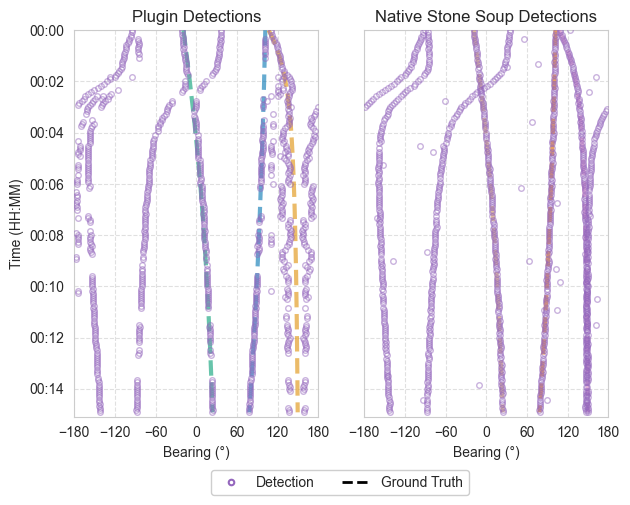

In [14]:
# plot nereus detections and ss detections side by side


fig1, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

style_guide = {
    "figure": {
        "figsize": (4, 4),
        "font_size": 10
    },
    "legend": {
        "display": False,  # Disable legend on RHS plot
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=[],
    all_detections=detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True,
    ax=axs[0],
)
axs[0].set_title("Plugin Detections")

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=[],
    all_detections=ss_detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True,
    ax=axs[1],
)
axs[1].set_ylabel("")
axs[1].set_title(f"Native Stone Soup Detections")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
           markeredgecolor='#9467bd', markersize=4, markeredgewidth=1.5, 
           label='Detection', linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label='Ground Truth'),
]

plt.legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(-0.1, -0.12), ncol=2, 
              fancybox=True, shadow=False, frameon=True, framealpha=0.95)


plt.savefig("figs/multi_target_plugin_vs_ss_det.png", dpi=300, bbox_inches='tight')

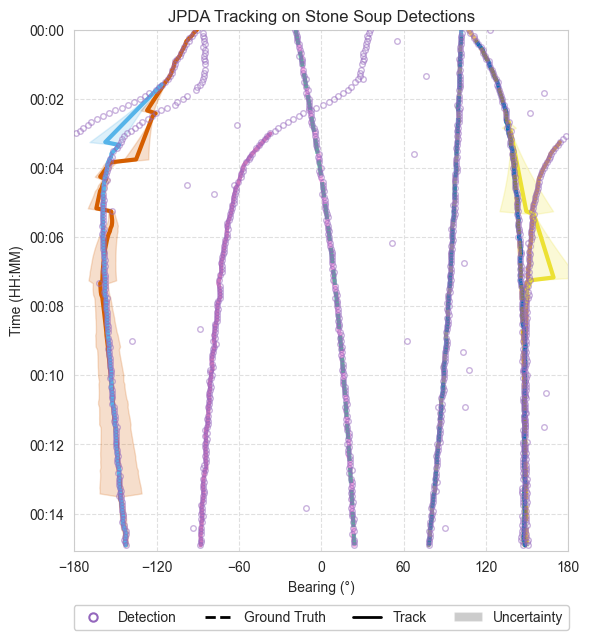

In [15]:
# JPDA tracking on Stone Soup detections
# ============================================================================
# Models
# ============================================================================
transition_model = ConstantVelocity(0.0000001)
predictor = KalmanPredictor(transition_model)

measurement_model = LinearGaussian(
    ndim_state=2,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(deg_std)**2]])
)
updater = ExtendedKalmanUpdater(measurement_model=measurement_model)

# ============================================================================
# JPDA for main tracking
# ============================================================================
FOV_RAD = np.deg2rad(360)
expected_false_alarms_per_scan = 1
clutter_spatial_density = expected_false_alarms_per_scan / FOV_RAD

jpda_hypothesiser = PDAHypothesiser(
    predictor=predictor,
    updater=updater,
    clutter_spatial_density=clutter_spatial_density,
    prob_detect=0.95
)
jpda_associator = JPDA(hypothesiser=jpda_hypothesiser)

# ============================================================================
# GNN for initiation (single-hypothesis, avoids MultipleHypothesis issue)
# ============================================================================
init_hypothesiser = DistanceHypothesiser(
    predictor=predictor,
    updater=updater,
    measure=Mahalanobis(),
    missed_distance=1.0
)
init_associator = GNNWith2DAssignment(init_hypothesiser)

# ============================================================================
# Track management
# ============================================================================
deleter = CovarianceBasedDeleter(covar_trace_thresh=0.2)

relative_bearing_ground_truth = relative_bearing_ground_truths[0]
initial_bearing = float(relative_bearing_ground_truth[0].state_vector[0]) + np.random.normal(0, np.deg2rad(2))
initial_bearing = mod_bearing(initial_bearing)

prior_state = GaussianState(
    np.array([[initial_bearing], [0.0]]),
    np.diag([np.deg2rad(0.5)**2, np.deg2rad(0.5)**2]),
    timestamp=SIM_PARAMS["start_time"]
)
Bearing(prior_state.state_vector[0,0])

initiator = MultiMeasurementInitiator(
    prior_state=prior_state,
    measurement_model=measurement_model,
    deleter=deleter,
    data_associator=init_associator, 
    updater=updater,
    min_points=4,
)

tracks, all_tracks = set(), set()

# ============================================================================
# Main loop
# ============================================================================
for timestamp, detections in stone_soup_detections:

    # Wrap detections
    for det in detections:
        det.state_vector[0, 0] = mod_bearing(float(det.state_vector[0, 0]))

    # JPDA association for existing tracks (convert detections list to set)
    detections_set = set(detections)
    associations = jpda_associator.associate(set(tracks), detections_set, timestamp)

    associated_detections = set()

    for track in list(tracks):
        track_hypotheses = associations[track]  # MultipleHypothesis

        posterior_states = []
        posterior_weights = []

        for hyp in track_hypotheses:
            if (hyp.measurement is None) or isinstance(hyp.measurement, MissedDetection):
                state = hyp.prediction
                Bearing(state.state_vector[0,0])
            else:
                state = updater.update(hyp)
                Bearing(state.state_vector[0,0])
                associated_detections.add(hyp.measurement)

            posterior_states.append(state)
            posterior_weights.append(float(hyp.probability))

        means = StateVectors([s.state_vector for s in posterior_states])
        covars = np.stack([s.covar for s in posterior_states], axis=2)
        weights = np.asarray(posterior_weights, dtype=float)
        if weights.sum() > 0:
            weights /= weights.sum()

        post_mean, post_covar = gm_reduce_single(means, covars, weights)
        post_mean = post_mean.copy()
        post_mean[0, 0] = mod_bearing(float(post_mean[0, 0]))

        track.append(GaussianStateUpdate(post_mean, post_covar, track_hypotheses, timestamp))

    # Delete and initiate (initiation uses GNN associator)
    tracks -= deleter.delete_tracks(tracks)
    tracks |= initiator.initiate(detections_set - associated_detections, timestamp)
    all_tracks |= tracks

# min_track_length = 4  # e.g., require 4 timesteps

# tracks = {t for t in tracks if len(t) >= min_track_length}
# all_tracks = {t for t in all_tracks if len(t) >= min_track_length}

# Plot results using Stone Soup detections
style_guide = {
    "figure": {
        "figsize": (6, 6),
        "font_size": 10
    },
    "legend": {
        "display": False,  # Disable automatic legend
    },
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

ax = plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=tracks,
    all_detections=ss_detections_for_plotter,  # Use Stone Soup detections
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)

ax.set_title("JPDA Tracking on Stone Soup Detections")

# Create custom legend with items in a row
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
           markeredgecolor='#9467bd', markersize=6, markeredgewidth=1.5, 
           label='Detection', linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label='Ground Truth'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=2, 
           label='Track'),
    Patch(facecolor='black', alpha=0.2, label='Uncertainty'),
]

ax.legend(handles=legend_elements, loc='upper center', 
          bbox_to_anchor=(0.5, -0.09), ncol=4, 
          fancybox=True, shadow=False, frameon=True, framealpha=0.95)

# RTRS TL BACKGROUND

Computing RTRS TL field at timestep 0...
Grid size: 239 x 239 = 57121 points
Source: Platform position (-10463.5, -7113.0, -50.0)
[  0.           3.06122449   6.12244898   9.18367347  12.24489796
  15.30612245  18.36734694  21.42857143  24.48979592  27.55102041
  30.6122449   33.67346939  36.73469388  39.79591837  42.85714286
  45.91836735  48.97959184  52.04081633  55.10204082  58.16326531
  61.2244898   64.28571429  67.34693878  70.40816327  73.46938776
  76.53061224  79.59183673  82.65306122  85.71428571  88.7755102
  91.83673469  94.89795918  97.95918367 101.02040816 104.08163265
 107.14285714 110.20408163 113.26530612 116.32653061 119.3877551
 122.44897959 125.51020408 128.57142857 131.63265306 134.69387755
 137.75510204 140.81632653 143.87755102 146.93877551 150.        ]
Running RTRS simulation...


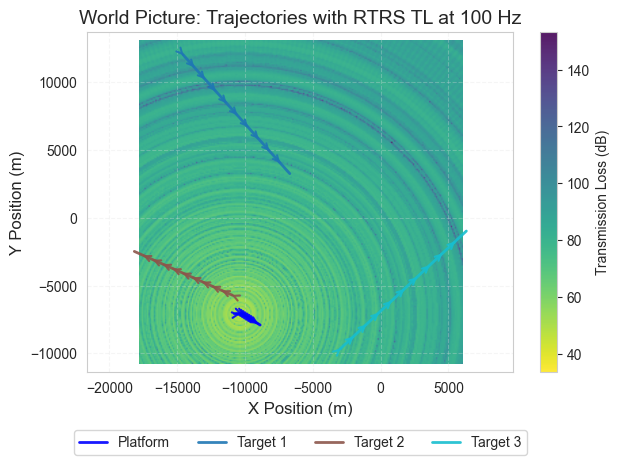

In [16]:
# ============================================================================
# RTRS TL BACKGROUND
# ============================================================================

import rtrs

# Plot: Trajectories in Cartesian space with RTRS TL background
fig_tl, ax_tl = plt.subplots()

# Extract platform positions (already computed above)
# platform_x, platform_y, array_x, array_y

# Select timestep for TL computation
tl_timestep_idx = 0  # 0 = first, len(timesteps)//2 = middle, -1 = last
tl_timestep = timesteps[tl_timestep_idx]

# Get array position at selected timestep
selected_platform_state = platform.get_platform_state_at(tl_timestep)
array_ref_pos = selected_platform_state.array.ref_state_vector

# Create spatial grid with extended range
all_x = platform_x + [state.state_vector[0] for gt in target_ground_truths for state in gt]
all_y = platform_y + [state.state_vector[2] for gt in target_ground_truths for state in gt]

# Determine the data range
data_x_range = (min(all_x), max(all_x))
data_y_range = (min(all_y), max(all_y))
data_x_span = data_x_range[1] - data_x_range[0]
data_y_span = data_y_range[1] - data_y_range[0]
x_center = (data_x_range[0] + data_x_range[1]) / 2
y_center = (data_y_range[0] + data_y_range[1]) / 2

# Add padding to y range
padding_factor = 1.1
y_range = (y_center - data_y_span / 2 * padding_factor, y_center + data_y_span / 2 * padding_factor)
y_span_total = y_range[1] - y_range[0]

# Set x range to match y range span (for square grid with equal aspect)
x_range = (x_center - y_span_total / 2, x_center + y_span_total / 2)

grid_resolution = 100  # meters (coarser for RTRS speed)
x_grid_vals = np.arange(x_range[0], x_range[1], grid_resolution)
y_grid_vals = np.arange(y_range[0], y_range[1], grid_resolution)

print(f"Computing RTRS TL field at timestep {tl_timestep_idx}...")
print(f"Grid size: {len(x_grid_vals)} x {len(y_grid_vals)} = {len(x_grid_vals) * len(y_grid_vals)} points")

# TL Configuration: Choose source type
# ===============================================================
use_platform_as_source = True  # Platform position as source
use_custom_source = False  # Custom fixed source position

if use_platform_as_source:
    source_x = array_ref_pos[0]
    source_y = array_ref_pos[1]
    source_z = array_ref_pos[2]
    print(f"Source: Platform position ({source_x:.1f}, {source_y:.1f}, {source_z:.1f})")
elif use_custom_source:
    source_x, source_y, source_z = 0.0, 0.0, -50.0  # Set custom source position
    print(f"Source: Custom position ({source_x:.1f}, {source_y:.1f}, {source_z:.1f})")

# Build SSP from PROP_PARAMS (Linear profile)
z_ssp = np.linspace(0.0, -PROP_PARAMS["bathymetry"].depth, 50)
print(z_ssp)
# Linear SSP: c(z) = surface_speed + gradient * |z|
surface_speed = PROP_PARAMS["ssp"].surface_speed
gradient = PROP_PARAMS["ssp"].gradient
c_ssp = surface_speed + gradient * np.abs(z_ssp)

# Tile SSP to create 3D grid (2x2 spatial grid)
ssp_3d = np.tile(c_ssp, (2, 2, 1))
ssp_3d_flat = ssp_3d.flatten(order='C')

# Get bathymetry depth
bathy_depth = -PROP_PARAMS["bathymetry"].depth

# Build RTRS configuration
env_config = {
    "ssp": {
        "x_ssp_m": [x_range[0], x_range[1]],
        "y_ssp_m": [y_range[0], y_range[1]],
        "z_ssp_m": list(z_ssp),  # Negative for depth
        "c_m_s": list(ssp_3d_flat)
    },
    "bathymetry": {
        "x_bty_m": [x_range[0], x_range[1]],
        "y_bty_m": [y_range[0], y_range[1]],
        "z_bty_m": [bathy_depth, bathy_depth, bathy_depth, bathy_depth],
        "density_g_cm3": 1.6,
        "c_bty_m_s": 1700.0,
        "attenuation_db": 0.0
    },
    "source": {
        "position": [source_x, source_y, -source_z],
        "freq_hz": [100.0],
        "launch_elev_deg": np.linspace(-25.0, 25.0, 50).tolist(),
        "launch_azim_deg": np.linspace(-180.0, 180.0, 360).tolist()
    },
    "receivers": {
        "config_type": "grid",
        "x_rcvr_m": list(x_grid_vals),
        "y_rcvr_m": list(y_grid_vals),
        "z_rcvr_m": [-array_ref_pos[2]]  # Receiver depth at array depth
    },
    "beam": {
        "step_m": PROP_PARAMS["step_m"],
        "max_steps": 100000,
        "max_range_m": max(x_range[1] - x_range[0], y_range[1] - y_range[0]) * 1.5
    }
}

print("Running RTRS simulation...")
result = rtrs.run_simulation(env_config)

# Extract pressure field
pf = result["pressure_field"]
shape = tuple(pf["shape"])  # (nfreq, nx, ny, nz)

# Reconstruct complex pressure array
re = np.array(pf["pressure_re"], dtype=np.float32).reshape(shape)
im = np.array(pf["pressure_im"], dtype=np.float32).reshape(shape)
pressure = re + 1j * im

# Convert to TL (transmission loss)
tl = -20 * np.log10(np.abs(pressure) + 1e-30)  # Add small value to avoid log(0)

# Extract TL at receiver depth (z_idx=0 since we only have one depth)
TL_grid = tl[0, :, :, 0].T  # Transpose to match (y, x) indexing for imshow

# Plot TL as background using imshow
extent = [x_range[0], x_range[1], y_range[0], y_range[1]]
im_tl = ax_tl.imshow(TL_grid, extent=extent, origin='lower', cmap='viridis_r', 
                     alpha=0.9, aspect='equal', interpolation='bilinear')
cbar_tl = plt.colorbar(im_tl, ax=ax_tl, label='Transmission Loss (dB)')

# Plot platform trajectory with direction arrows
ax_tl.plot(platform_x, platform_y, 'b-', label='Platform', linewidth=2, alpha=0.9)

# Add direction arrows for platform
arrow_interval = max(1, len(platform_x) // 10)
for i in range(0, len(platform_x) - 1, arrow_interval):
    dx = platform_x[i + 1] - platform_x[i]
    dy = platform_y[i + 1] - platform_y[i]
    ax_tl.annotate('', xy=(platform_x[i + 1], platform_y[i + 1]), 
                   xytext=(platform_x[i], platform_y[i]),
                   arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, alpha=0.9))

# Plot target trajectories with different colors
colors = plt.cm.tab10(np.linspace(0, 1, NUM_TARGETS))

for target_idx, target_ground_truth in enumerate(target_ground_truths):
    target_x = [state.state_vector[0] for state in target_ground_truth]
    target_y = [state.state_vector[2] for state in target_ground_truth]
    
    color = colors[target_idx]
    ax_tl.plot(target_x, target_y, '-', color=color, 
               label=f'Target {target_idx + 1}', linewidth=2, alpha=0.9)
    
    # Add direction arrows for each target
    for i in range(0, len(target_x) - 1, arrow_interval):
        dx = target_x[i + 1] - target_x[i]
        dy = target_y[i + 1] - target_y[i]
        ax_tl.annotate('', xy=(target_x[i + 1], target_y[i + 1]), 
                       xytext=(target_x[i], target_y[i]),
                       arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.9))

ax_tl.set_xlabel('X Position (m)', fontsize=12)
ax_tl.set_ylabel('Y Position (m)', fontsize=12)
ax_tl.set_title(f'World Picture: Trajectories with RTRS TL at 100 Hz', fontsize=14)
ax_tl.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=4)
ax_tl.grid(True, alpha=0.3)
ax_tl.axis('equal')
plt.tight_layout()

# SUMMARY

In [17]:
print()
print("=" * 80)
print("Random Scenario Summary:")
print("=" * 80)
print(f"  Seed: {seed}")
print(f"  Number of Targets: {NUM_TARGETS}")
print(f"  Simulation Duration: {total_duration_s} s across {SIM_PARAMS['num_steps']} timesteps")
print(f"  Timestep Interval: {SIM_PARAMS['time_interval'].total_seconds()} s")
print(f"  Array: {ARRAY_PARAMS['num_sensors']} sensors, {ARRAY_PARAMS['sensor_spacing']} m spacing")
print(f"  Signal Sampling Rate: {SIGNAL_PARAMS['sampling_rate_hz']} Hz")
print(f"  Ambient Noise Level: {20 * np.log10(AMBIENT_NOISE_PARAMS['amplitude_upa']):.1f} dB re 1 µPa")
print(f"  Steering Directions: {len(BF_PARAMS['steering_azimuths_rad'])}")
print()
print("  Platform Initial State:")
print(f"    Position: ({SHIP_PARAMS['start_vector'][0]:.0f}, {SHIP_PARAMS['start_vector'][2]:.0f}) m")
print(f"    Velocity: ({SHIP_PARAMS['start_vector'][1]:.1f}, {SHIP_PARAMS['start_vector'][3]:.1f}) m/s")
print()
print(f"  Platform Maneuvers ({len(maneuver_models)} total):")
for i, desc in enumerate(maneuver_descriptions):
    print(f"    {i+1}. {desc} @ timestep {maneuver_timesteps[i]}")
print()
for target_idx, TARGET_PARAMS in enumerate(TARGETS):
    print(f"  Target {target_idx + 1}:")
    print(f"    Frequencies: {TARGET_PARAMS['frequencies_hz']} Hz")
    print(f"    Amplitudes: {20 * np.log10(TARGET_PARAMS['amplitudes_upa'])} dB re 1 µPa")
    print(f"    Start Position: ({TARGET_PARAMS['start_vector'][0]:.0f}, {TARGET_PARAMS['start_vector'][2]:.0f}) m")
    print(f"    Velocity: ({TARGET_PARAMS['start_vector'][1]:.1f}, {TARGET_PARAMS['start_vector'][3]:.1f}) m/s")



Random Scenario Summary:
  Seed: 12
  Number of Targets: 3
  Simulation Duration: 900.0 s across 180 timesteps
  Timestep Interval: 5.0 s
  Array: 200 sensors, 0.5 m spacing
  Signal Sampling Rate: 500.0 Hz
  Ambient Noise Level: 49.2 dB re 1 µPa
  Steering Directions: 361

  Platform Initial State:
    Position: (-10375, -7101) m
    Velocity: (1.9, 0.3) m/s

  Platform Maneuvers (6 total):
    1. Straight (70s) @ timestep 0
    2. Right Turn 40° (40s) @ timestep 14
    3. Straight (215s) @ timestep 22
    4. Straight (180s) @ timestep 65
    5. Straight (275s) @ timestep 101
    6. Straight (120s) @ timestep 156

  Target 1:
    Frequencies: [190.23939881 174.22871969  25.39536587 116.21455476] Hz
    Amplitudes: [101.35424004  89.05813982  91.25742529  96.09124777] dB re 1 µPa
    Start Position: (-14563, 12021) m
    Velocity: (8.8, -9.8) m/s
  Target 2:
    Frequencies: [147.95891217  82.32465835  83.56331759 196.16016383] Hz
    Amplitudes: [94.06844667 99.24252447 91.34380175 9